In [1]:
!pip install biopython scikit-learn pandas numpy matplotlib seaborn -q
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.9 MB/s eta 0:00:00
Setup complete.


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from Bio import Entrez
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, average_precision_score,
    precision_recall_curve
)
from sklearn.feature_extraction.text import CountVectorizer

RANDOM_SEED   = 42
WINDOW_SIZE   = 50
MAX_KMERS     = 256
N_TREES       = 200
ENTREZ_EMAIL  = "bilalzaib.microbio@gmail.com"

DOMAINS = {
    'TAD1':       (1,   40),
    'TAD2':       (41,  67),
    'Proline':    (68,  101),
    'DBD':        (102, 292),
    'Linker':     (293, 324),
    'Tetra':      (325, 356),
    'Regulatory': (357, 393),
}
HOTSPOT_CODONS = {175, 245, 248, 249, 273, 282}


TP53_START = 7661779
TP53_END   = 7687538
FETCH_PAD  = 200

print("Constants locked.")

Constants locked.


In [3]:
def get_domain(codon_number):
    for name, (start, end) in DOMAINS.items():
        if start <= codon_number <= end:
            return name
    return 'Unknown'

def get_first_codon(protein_change):
    if pd.isna(protein_change):
        return None
    first_entry = str(protein_change).split(',')[0].strip()
    match = re.search(r'(\d+)', first_entry)
    return int(match.group(1)) if match else None

def parse_spdi(spdi_string):
    try:
        parts = str(spdi_string).split(':')
        position = int(parts[1])
        return position, parts[2], parts[3]
    except Exception:
        return None, None, None

def is_transition(ref_base, alt_base):
    if ref_base is None or alt_base is None:
        return -1
    transitions = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
    return 1 if (ref_base, alt_base) in transitions else 0

def extract_genomic_window(genomic_seq, idx_in_seq, window=WINDOW_SIZE):
    start = max(0, idx_in_seq - window)
    end = min(len(genomic_seq), idx_in_seq + window + 1)
    return genomic_seq[start:end]

print("Helper functions defined.")

Helper functions defined.


In [4]:
print("Fetching TP53 genomic region from NCBI (NC_000017.11)...")
Entrez.email = ENTREZ_EMAIL

fetch_start = TP53_START - FETCH_PAD
fetch_end   = TP53_END + FETCH_PAD

handle = Entrez.efetch(
    db="nucleotide",
    id="NC_000017.11",
    rettype="fasta",
    retmode="text",
    seq_start=fetch_start,
    seq_stop=fetch_end
)
from Bio import SeqIO
genomic_record = SeqIO.read(handle, "fasta")
handle.close()

genomic_seq = str(genomic_record.seq).upper()
print(f"Genomic region fetched: {len(genomic_seq)} bp ({fetch_end - fetch_start + 1})")

def genomic_pos_to_index(spdi_pos_0based):

    return spdi_pos_0based - (fetch_start - 1)

Fetching TP53 genomic region from NCBI (NC_000017.11)...
Genomic region fetched: 26160 bp (26160)


In [29]:
print("Loading ClinVar data...")
df_raw = pd.read_csv('/content/clinvar_result.txt', sep='\t', low_memory=False)
print(f"Raw rows: {len(df_raw)}")

keep_labels = [
    'Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic',
    'Pathogenic/Likely pathogenic/Pathogenic, low penetrance',
    'Benign', 'Likely benign', 'Likely benign/Benign', 'Benign/Likely benign'
]

df_raw_filtered = df_raw[
    df_raw['Germline classification'].isin(keep_labels)
].reset_index(drop=True)

print(f"After VUS/conflicting exclusion: {len(df_raw_filtered)} (expect 1470)")

pathogenic_set = {
    'Pathogenic',
    'Likely pathogenic',
    'Pathogenic/Likely pathogenic',
    'Pathogenic/Likely pathogenic/Pathogenic, low penetrance'
}

records = []
original_indices = []

excluded_spdi_fail = 0
excluded_refbase_mismatch = 0
excluded_short_window = 0

for original_idx, row in df_raw_filtered.iterrows():

    label = 1 if row['Germline classification'] in pathogenic_set else 0

    position, ref_base, alt_base = parse_spdi(row['Canonical SPDI'])

    if position is None:
        excluded_spdi_fail += 1
        continue

    pos_idx = genomic_pos_to_index(position)

    if pos_idx < 0 or pos_idx >= len(genomic_seq):
        excluded_spdi_fail += 1
        continue

    actual_base = genomic_seq[pos_idx]

    if actual_base != ref_base.upper():
        excluded_refbase_mismatch += 1
        continue

    dna_window = extract_genomic_window(genomic_seq, pos_idx, WINDOW_SIZE)

    if len(dna_window) < 30:
        excluded_short_window += 1
        continue

    codon = get_first_codon(row['Protein change'])

    domain = get_domain(codon) if codon else 'Unknown'

    hotspot = int(codon in HOTSPOT_CODONS) if codon else 0

    rel_pos = (TP53_END - position) / (TP53_END - TP53_START)

    records.append({
        'sequence': dna_window,
        'label': label,
        'codon': codon if codon else 0,
        'rel_pos': rel_pos,
        'domain': domain,
        'is_hotspot': hotspot,
        'is_transition': is_transition(ref_base, alt_base),
        'ref_base': ref_base,
        'alt_base': alt_base
    })

    original_indices.append(original_idx)

df = pd.DataFrame(records)

# Preserve mapping to original ClinVar rows
df.index = original_indices

print("\n= INTEGRITY REPORT =")
print(f"SPDI parse / out-of-range failures: {excluded_spdi_fail}")
print(f"REF BASE MISMATCHES: {excluded_refbase_mismatch}")
print(f"Short window failures: {excluded_short_window}")
print(f"Final dataset: {len(df)} variants")
print(f"Pathogenic: {(df['label']==1).sum()} | Benign: {(df['label']==0).sum()}")

print("\nDomain breakdown:")
print(df['domain'].value_counts())

print("\nIndex preserved:", df.index.is_unique)

label_check = (
    df_raw_filtered.loc[df.index, 'Germline classification']
    .apply(lambda x: 1 if x in pathogenic_set else 0)
)

print("Label alignment:",
      (label_check.values == df['label'].values).all())
print ("=========================")

Loading ClinVar data...
Raw rows: 2739
After VUS/conflicting exclusion: 1470 (expect 1470)

= INTEGRITY REPORT =
SPDI parse / out-of-range failures: 1
REF BASE MISMATCHES: 0
Short window failures: 0
Final dataset: 1469 variants
Pathogenic: 410 | Benign: 1059

Domain breakdown:
domain
Unknown       992
DBD           388
TAD1           43
TAD2           18
Proline        17
Tetra           6
Linker          4
Regulatory      1
Name: count, dtype: int64

Index preserved: True
Label alignment: True


In [21]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED, stratify=df['label']
)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Test set — Pathogenic: {(test_df['label']==1).sum()} | Benign: {(test_df['label']==0).sum()}")

# Fit vectorizer on TRAIN sequences...
kmer_vectorizer = CountVectorizer(analyzer='char', ngram_range=(3, 4), max_features=MAX_KMERS)
X_kmers_train = kmer_vectorizer.fit_transform(train_df['sequence']).toarray()
X_kmers_test  = kmer_vectorizer.transform(test_df['sequence']).toarray()

def build_features(sub_df):
    X_bio = sub_df[['codon', 'rel_pos', 'is_hotspot', 'is_transition']].values
    ref_e = pd.get_dummies(sub_df['ref_base'], prefix='ref')
    alt_e = pd.get_dummies(sub_df['alt_base'], prefix='alt')
    dom_e = pd.get_dummies(sub_df['domain'], prefix='dom')
    return X_bio, ref_e, alt_e, dom_e

X_bio_train, ref_tr, alt_tr, dom_tr = build_features(train_df)
X_bio_test,  ref_te, alt_te, dom_te = build_features(test_df)

# Align dummy columns (test split may lack a category train has, or vice versa)
ref_te = ref_te.reindex(columns=ref_tr.columns, fill_value=0)
alt_te = alt_te.reindex(columns=alt_tr.columns, fill_value=0)
dom_te = dom_te.reindex(columns=dom_tr.columns, fill_value=0)

X_train = np.hstack([
    X_kmers_train, X_bio_train,
    ref_tr.astype(float).values, alt_tr.astype(float).values, dom_tr.astype(float).values
])
X_test = np.hstack([
    X_kmers_test, X_bio_test,
    ref_te.astype(float).values, alt_te.astype(float).values, dom_te.astype(float).values
])
y_train = train_df['label'].values
y_test  = test_df['label'].values

feature_names = (
    list(kmer_vectorizer.get_feature_names_out()) +
    ['codon_pos', 'rel_pos', 'is_hotspot', 'is_transition'] +
    list(ref_tr.columns) + list(alt_tr.columns) + list(dom_tr.columns)
)

print(f"Feature matrix: train={X_train.shape}, test={X_test.shape}")

model = RandomForestClassifier(
    n_estimators=N_TREES, min_samples_split=3,
    class_weight='balanced', random_state=RANDOM_SEED
)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_predictions = model.predict(X_test)

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='roc_auc'
)
print(f"5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


Train: 1175 | Test: 294
Test set — Pathogenic: 82 | Benign: 212
Feature matrix: train=(1175, 276), test=(294, 276)
5-fold CV AUC: 0.9611 +/- 0.0198


In [24]:
auc_roc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_predictions)
recall = recall_score(y_test, y_predictions)          # sensitivity
precision = precision_score(y_test, y_predictions)    # PPV
f1 = f1_score(y_test, y_predictions)

tn, fp, fn, tp = confusion_matrix(y_test, y_predictions).ravel()
spec = tn / (tn + fp)
npv = tn / (tn + fn)

print("RESULTS")
print(f"AUC-ROC      : {auc_roc:.4f}")
print(f"AUPRC        : {auprc:.4f}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Sensitivity  : {recall:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"PPV          : {precision:.4f}")
print(f"NPV          : {npv:.4f}")
print(f"F1           : {f1:.4f}")
print(f"Confusion: TN={tn} FP={fp} FN={fn} TP={tp}")
print("===================================")

RESULTS
AUC-ROC      : 0.9511
AUPRC        : 0.8772
Accuracy     : 0.9048
Sensitivity  : 0.8780
Specificity  : 0.9151
PPV          : 0.8000
NPV          : 0.9510
F1           : 0.8372
Confusion: TN=194 FP=18 FN=10 TP=72


In [8]:
n_bootstrap = 1000
rng = np.random.RandomState(42)
y_test_arr = np.asarray(y_test)
y_pred_proba_arr = np.asarray(y_pred_proba)

In [9]:
rng = np.random.RandomState(42)
y_test_arr = np.asarray(y_test)
y_pred_proba_arr = np.asarray(y_pred_proba)

aucs, senss, specs = [], [], []
for _ in range(n_bootstrap):
    idx = rng.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    y_t, y_s = y_test_arr[idx], y_pred_proba_arr[idx]
    if len(np.unique(y_t)) < 2:
        continue
    aucs.append(roc_auc_score(y_t, y_s))
    y_p = (y_s >= 0.5).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_t, y_p).ravel()
    senss.append(tp_/(tp_+fn_) if (tp_+fn_) > 0 else np.nan)
    specs.append(tn_/(tn_+fp_) if (tn_+fp_) > 0 else np.nan)

print(f"AUC-ROC: {np.mean(aucs):.4f} (95% CI: {np.percentile(aucs,2.5):.4f}-{np.percentile(aucs,97.5):.4f})")
print(f"Sensitivity: {np.nanmean(senss):.4f} (95% CI: {np.nanpercentile(senss,2.5):.4f}-{np.nanpercentile(senss,97.5):.4f})")
print(f"Specificity: {np.nanmean(specs):.4f} (95% CI: {np.nanpercentile(specs,2.5):.4f}-{np.nanpercentile(specs,97.5):.4f})")

AUC-ROC: 0.9509 (95% CI: 0.9221-0.9736)
Sensitivity: 0.8775 (95% CI: 0.8056-0.9445)
Specificity: 0.9148 (95% CI: 0.8756-0.9496)


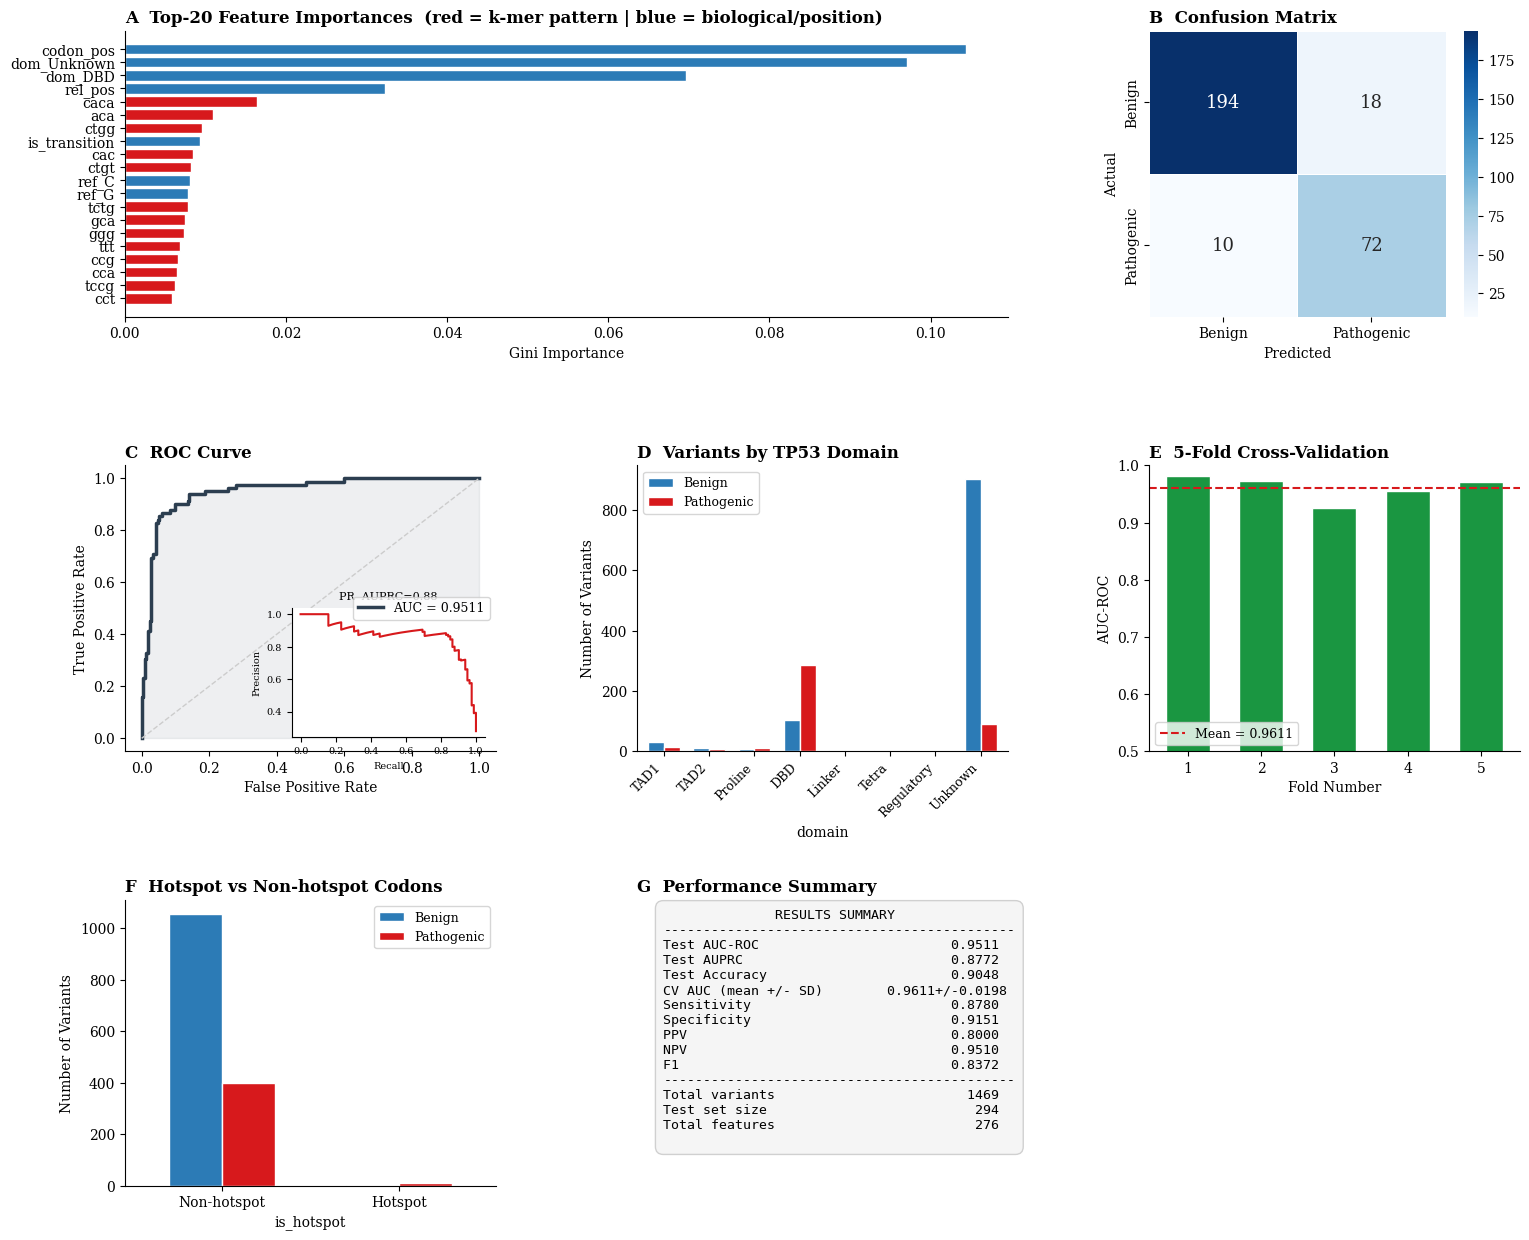

In [10]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREEN = '#2c7bb6', '#d7191c', '#1a9641'

fig = plt.figure(figsize=(18, 15))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

ax_a = fig.add_subplot(gs[0, :2])
importance_df = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_}).nlargest(20, 'importance')
bio_feats = {'codon_pos','rel_pos','is_hotspot','is_transition'}
colors = [BLUE if (f.startswith(('dom_','ref_','alt_')) or f in bio_feats) else RED for f in importance_df['feature']]
ax_a.barh(importance_df['feature'], importance_df['importance'], color=colors, edgecolor='white')
ax_a.invert_yaxis()
ax_a.set_xlabel('Gini Importance')
ax_a.set_title('A  Top-20 Feature Importances  (red = k-mer pattern | blue = biological/position)', loc='left', fontweight='bold')

ax_b = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_b, xticklabels=['Benign','Pathogenic'], yticklabels=['Benign','Pathogenic'], annot_kws={'size':13}, linewidths=0.5)
ax_b.set_xlabel('Predicted'); ax_b.set_ylabel('Actual')
ax_b.set_title('B  Confusion Matrix', loc='left', fontweight='bold')

ax_c = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax_c.plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'AUC = {auc_roc:.4f}')
ax_c.fill_between(fpr, tpr, alpha=0.08, color='#2c3e50')
ax_c.plot([0,1],[0,1],'--', color='#cccccc', lw=1)
ax_c.set_xlabel('False Positive Rate'); ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C  ROC Curve', loc='left', fontweight='bold')
ax_c.legend(fontsize=9)
ax_ins = ax_c.inset_axes([0.45,0.05,0.52,0.45])
pr_p, pr_r, _ = precision_recall_curve(y_test, y_pred_proba)
ax_ins.plot(pr_r, pr_p, color=RED, lw=1.5)
ax_ins.set_title(f'PR  AUPRC={auprc:.2f}', fontsize=8)
ax_ins.set_xlabel('Recall', fontsize=7); ax_ins.set_ylabel('Precision', fontsize=7); ax_ins.tick_params(labelsize=7)

ax_d = fig.add_subplot(gs[1, 1])
domain_order = [d for d in list(DOMAINS.keys())+['Unknown'] if d in df['domain'].unique()]
domain_table = df.groupby(['domain','label']).size().unstack(fill_value=0).rename(columns={0:'Benign',1:'Pathogenic'}).reindex(domain_order)
domain_table.plot(kind='bar', ax=ax_d, color=[BLUE,RED], edgecolor='white', width=0.7)
ax_d.set_xticklabels(ax_d.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax_d.set_ylabel('Number of Variants')
ax_d.set_title('D  Variants by TP53 Domain', loc='left', fontweight='bold')
ax_d.legend(fontsize=9)

ax_e = fig.add_subplot(gs[1, 2])
ax_e.bar(range(1,6), cv_scores, color=GREEN, edgecolor='white', width=0.6)
ax_e.axhline(cv_scores.mean(), color=RED, linestyle='--', lw=1.5, label=f'Mean = {cv_scores.mean():.4f}')
ax_e.set_xlabel('Fold Number'); ax_e.set_ylabel('AUC-ROC'); ax_e.set_ylim(0.5,1.0)
ax_e.set_title('E  5-Fold Cross-Validation', loc='left', fontweight='bold')
ax_e.legend(fontsize=9)

ax_f = fig.add_subplot(gs[2, 0])
hotspot_table = df.groupby(['is_hotspot','label']).size().unstack(fill_value=0).rename(columns={0:'Benign',1:'Pathogenic'}).rename(index={0:'Non-hotspot',1:'Hotspot'})
hotspot_table.plot(kind='bar', ax=ax_f, color=[BLUE,RED], edgecolor='white', width=0.6)
ax_f.set_xticklabels(ax_f.get_xticklabels(), rotation=0)
ax_f.set_ylabel('Number of Variants')
ax_f.set_title('F  Hotspot vs Non-hotspot Codons', loc='left', fontweight='bold')
ax_f.legend(fontsize=9)

ax_g = fig.add_subplot(gs[2, 1:])
ax_g.axis('off')
summary = (f"{'RESULTS SUMMARY':^44}\n{'-'*44}\n"
           f"{'Test AUC-ROC':<28}{auc_roc:>14.4f}\n{'Test AUPRC':<28}{auprc:>14.4f}\n"
           f"{'Test Accuracy':<28}{accuracy:>14.4f}\n{'CV AUC (mean +/- SD)':<28}{cv_scores.mean():.4f}+/-{cv_scores.std():.4f}\n"
           f"{'Sensitivity':<28}{recall:>14.4f}\n{'Specificity':<28}{spec:>14.4f}\n"
           f"{'PPV':<28}{precision:>14.4f}\n{'NPV':<28}{npv:>14.4f}\n{'F1':<28}{f1:>14.4f}\n"
           f"{'-'*44}\n{'Total variants':<28}{len(df):>14}\n{'Test set size':<28}{len(X_test):>14}\n"
          f"{'Total features':<28}{X_train.shape[1]:>14}\n")
ax_g.text(0.03, 0.97, summary, transform=ax_g.transAxes, fontsize=9.5, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#f4f4f4', edgecolor='#cccccc', alpha=0.9))
ax_g.set_title('G  Performance Summary', loc='left', fontweight='bold')

plt.savefig('Figure1  TP53 Gene Specific.png', dpi=300, bbox_inches='tight')
plt.show()

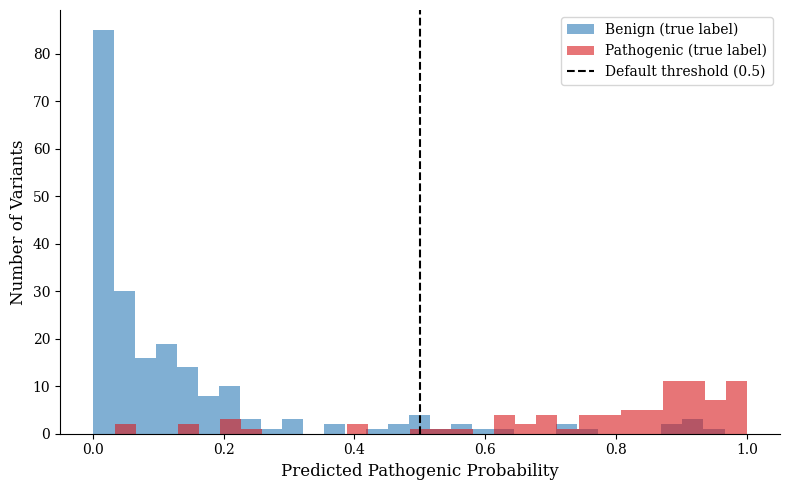

In [11]:
plt.figure(figsize=(8,5))
plt.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, color=BLUE, label='Benign (true label)')
plt.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, color=RED, label='Pathogenic (true label)')
plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Default threshold (0.5)')
plt.xlabel('Predicted Pathogenic Probability', fontsize=12)
plt.ylabel('Number of Variants', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Figure2 probability dist.png', dpi=300, bbox_inches='tight')
plt.show()

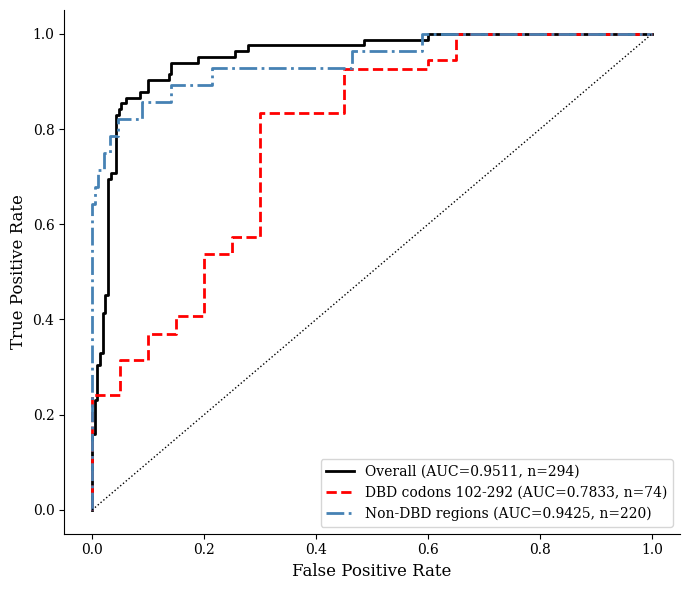

In [12]:
test_codons = test_df['codon'].values
dbd_mask = (test_codons >= 102) & (test_codons <= 292)
non_dbd_mask = ~dbd_mask

fpr_all, tpr_all, _ = roc_curve(y_test, y_pred_proba)
fpr_dbd, tpr_dbd, _ = roc_curve(y_test[dbd_mask], y_pred_proba[dbd_mask])
fpr_non, tpr_non, _ = roc_curve(y_test[non_dbd_mask], y_pred_proba[non_dbd_mask])
auc_dbd = roc_auc_score(y_test[dbd_mask], y_pred_proba[dbd_mask])
auc_non = roc_auc_score(y_test[non_dbd_mask], y_pred_proba[non_dbd_mask])

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(fpr_all, tpr_all, color='black', lw=2, label=f'Overall (AUC={auc_roc:.4f}, n={len(y_test)})')
ax.plot(fpr_dbd, tpr_dbd, color='red', lw=2, linestyle='--', label=f'DBD codons 102-292 (AUC={auc_dbd:.4f}, n={dbd_mask.sum()})')
ax.plot(fpr_non, tpr_non, color='steelblue', lw=2, linestyle='-.', label=f'Non-DBD regions (AUC={auc_non:.4f}, n={non_dbd_mask.sum()})')
ax.plot([0,1],[0,1],'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('Figure3 DBD stratified.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print(f"DBD: AUC={auc_dbd:.4f}, n={dbd_mask.sum()}")
print(f"Non-DBD: AUC={auc_non:.4f}, n={non_dbd_mask.sum()}")

#get sensitivity/specificity
from sklearn.metrics import confusion_matrix, recall_score
y_pred = (y_pred_proba >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test[dbd_mask], y_pred[dbd_mask]).ravel()
print(f"DBD: Sens={tp/(tp+fn):.4f} Spec={tn/(tn+fp):.4f}")

tn, fp, fn, tp = confusion_matrix(y_test[non_dbd_mask], y_pred[non_dbd_mask]).ravel()
print(f"Non-DBD: Sens={tp/(tp+fn):.4f} Spec={tn/(tn+fp):.4f}")

DBD: AUC=0.7833, n=74
Non-DBD: AUC=0.9425, n=220
DBD: Sens=0.9259 Spec=0.4000
Non-DBD: Sens=0.7857 Spec=0.9688


In [31]:
# ABLATION STUDY....
def build_kmer_only(train_seq, test_seq):
    vec = CountVectorizer(analyzer='char', ngram_range=(3, 4), max_features=MAX_KMERS)
    Xtr = vec.fit_transform(train_seq).toarray()
    Xte = vec.transform(test_seq).toarray()
    return Xtr, Xte

def build_bio_only(tr_df, te_df):
    def feats(d):
        X_bio = d[['codon', 'rel_pos', 'is_hotspot', 'is_transition']].values
        ref_e = pd.get_dummies(d['ref_base'], prefix='ref')
        alt_e = pd.get_dummies(d['alt_base'], prefix='alt')
        dom_e = pd.get_dummies(d['domain'], prefix='dom')
        return X_bio, ref_e, alt_e, dom_e
    bio_tr, ref_tr, alt_tr, dom_tr = feats(tr_df)
    bio_te, ref_te, alt_te, dom_te = feats(te_df)
    ref_te = ref_te.reindex(columns=ref_tr.columns, fill_value=0)
    alt_te = alt_te.reindex(columns=alt_tr.columns, fill_value=0)
    dom_te = dom_te.reindex(columns=dom_tr.columns, fill_value=0)
    Xtr = np.hstack([bio_tr, ref_tr.astype(float).values, alt_tr.astype(float).values, dom_tr.astype(float).values])
    Xte = np.hstack([bio_te, ref_te.astype(float).values, alt_te.astype(float).values, dom_te.astype(float).values])
    return Xtr, Xte

def eval_subset(Xtr, Xte, y_tr, y_te, label):
    m = RandomForestClassifier(n_estimators=N_TREES, min_samples_split=3,
                                class_weight='balanced', random_state=RANDOM_SEED)
    m.fit(Xtr, y_tr)
    proba = m.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    auc = roc_auc_score(y_te, proba)
    sens = recall_score(y_te, pred)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    spec = tn / (tn + fp)
    print(f"{label:35s} AUC={auc:.4f}  Sens={sens:.4f}  Spec={spec:.4f}")
    return auc, sens, spec

y_tr_arr = train_df['label'].values
y_te_arr = test_df['label'].values

print("====ABLATION STUDY (leak-free, on same split as primary model based on)====")

# Full feature set — X_train/X_test already built in Cell 5
full_res = eval_subset(X_train, X_test, y_tr_arr, y_te_arr, "Full feature set (k-mers + biological)")

# K-mers only
Xtr_kmer, Xte_kmer = build_kmer_only(train_df['sequence'], test_df['sequence'])
kmer_res = eval_subset(Xtr_kmer, Xte_kmer, y_tr_arr, y_te_arr, "Sequence k-mers only")

# Biological/positional only
Xtr_bio, Xte_bio = build_bio_only(train_df, test_df)
bio_res = eval_subset(Xtr_bio, Xte_bio, y_tr_arr, y_te_arr, "Biological/position features only")

====ABLATION STUDY (leak-free, on same split as primary model based on)====
Full feature set (k-mers + biological) AUC=0.9511  Sens=0.8780  Spec=0.9151
Sequence k-mers only                AUC=0.8246  Sens=0.7317  Spec=0.8160
Biological/position features only   AUC=0.8753  Sens=0.7073  Spec=0.9009


In [15]:
missense_test_mask = df_raw_filtered.loc[test_df.index, 'Molecular consequence'].str.contains('missense', case=False, na=False).values

y_test_missense = y_test[missense_test_mask]
y_proba_missense = y_pred_proba[missense_test_mask]

from sklearn.metrics import roc_auc_score, confusion_matrix
auc_missense = roc_auc_score(y_test_missense, y_proba_missense)
pred_missense = (y_proba_missense >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_missense, pred_missense).ravel()

print(f"Real missense subset: n={missense_test_mask.sum()} (pathogenic={y_test_missense.sum()}, benign={(y_test_missense==0).sum()})")
print(f"AUC={auc_missense:.4f}, Sens={tp/(tp+fn):.4f}, Spec={tn/(tn+fp):.4f}")

Real missense subset: n=75 (pathogenic=45, benign=30)
AUC=0.8563, Sens=0.9778, Spec=0.5333


In [34]:
import sys
import sklearn, pandas, numpy, Bio, matplotlib, seaborn

actual_versions = {
    'Python':       f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}",
    'scikit-learn': sklearn.__version__,
    'pandas':       pandas.__version__,
    'numpy':        numpy.__version__,
    'Biopython':    Bio.__version__,
    'matplotlib':   matplotlib.__version__,
    'seaborn':      seaborn.__version__,
}

for lib, version in actual_versions.items():
    print(f"{lib}: {version}")

Python: 3.12.13
scikit-learn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2
Biopython: 1.87
matplotlib: 3.10.0
seaborn: 0.13.2
